In [21]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [22]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [23]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [24]:
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:openai/gpt-oss-120b")

In [25]:
def chatbot(state:State):
    return {'messages':[llm.invoke(state['messages'])]}

In [26]:
graph_builder=StateGraph(State)
graph_builder.add_node('llm_chatbot',chatbot)

graph_builder.add_edge(START,'llm_chatbot')
graph_builder.add_edge('llm_chatbot',END)
graph=graph_builder.compile()

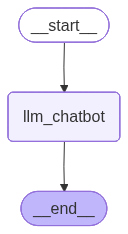

In [27]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(Exception)

In [29]:
from langchain_core.messages import HumanMessage

res=graph.invoke({'messages':HumanMessage(content="hi")})
res['messages'][-1].content

'Hello! How can I help you today?'